MODELO COM N=20
Equação Encontrada: PIO = 9.40 + 0.1645 * Idade

Métricas de Avaliação
MAE: 0.91
MSE: 1.6306
RMSE: 1.277
R2: 0.7982


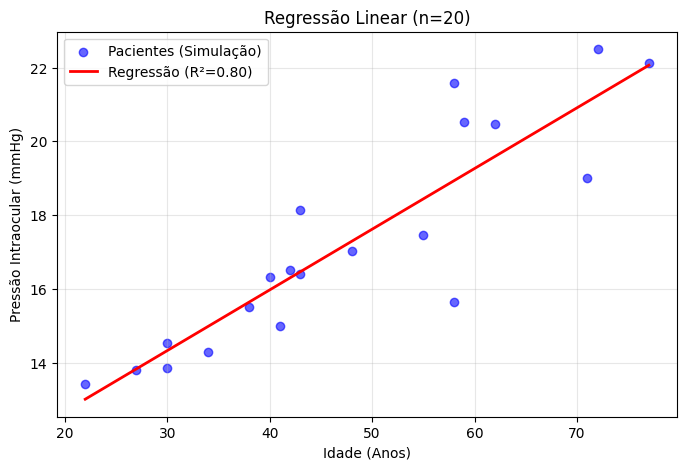

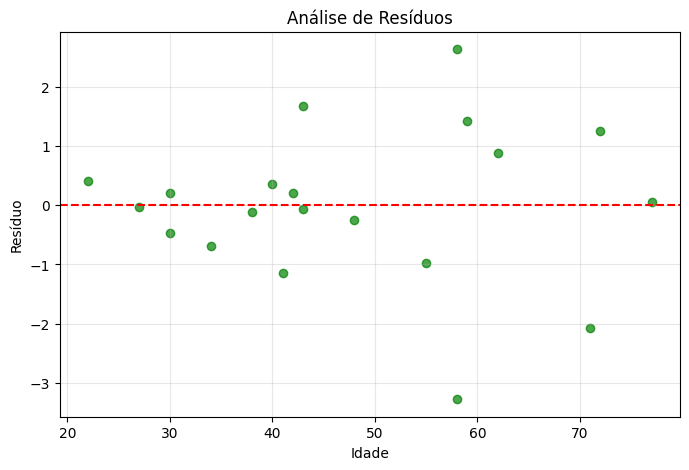

In [4]:
import pandas as pd
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt

def analise_regressao():

    np.random.seed(42)

    n_amostras = 20


    X = np.random.randint(20, 80, n_amostras)
    X.sort()


    ruido = np.random.normal(0, 1.5, n_amostras)
    Y = 10 + (0.15 * X) + ruido


    b1, b0 = np.polyfit(X, Y, 1)


    Y_hat = b0 + b1 * X

    residuos = Y - Y_hat
    sq_res = residuos**2

    # metricas
    MAE = np.abs(residuos).mean()
    MSE = sq_res.mean()
    RMSE = sqrt(MSE)

    Y_bar = Y.mean()
    SSE = sq_res.sum()
    SST = ((Y - Y_bar)**2).sum()
    R2 = 1 - SSE / SST

    # tabela
    df = pd.DataFrame({
        "Idade": X,
        "PIO Real": Y.round(2),
        "PIO Prevista": Y_hat.round(2),
        "Resíduo": residuos.round(2)
    })

    print(f"MODELO COM N={n_amostras}")
    print(f"Equação Encontrada: PIO = {b0:.2f} + {b1:.4f} * Idade")

    # salvando
    df.to_csv("dados_oftalmo.csv", index=False)

    metrics = {
        "MAE": round(MAE, 4),
        "MSE": round(MSE, 4),
        "RMSE": round(RMSE, 4),
        "R2": round(R2, 4)
    }

    print("\nMétricas de Avaliação")
    for k, v in metrics.items():
        print(f"{k}: {v}")

    # grafico 1: Regressão
    plt.figure(figsize=(8, 5))
    plt.scatter(X, Y, color="blue", alpha=0.6, label="Pacientes (Simulação)")
    plt.plot(X, Y_hat, color="red", linewidth=2, label=f"Regressão (R²={R2:.2f})")
    plt.xlabel("Idade (Anos)")
    plt.ylabel("Pressão Intraocular (mmHg)")
    plt.title(f"Regressão Linear (n={n_amostras})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('fig1_regressao_20.png')
    plt.show()

    # grafico 2: Resíduos
    plt.figure(figsize=(8, 5))
    plt.scatter(X, residuos, color="green", alpha=0.7)
    plt.axhline(y=0, color="red", linestyle="--")
    plt.xlabel("Idade")
    plt.ylabel("Resíduo")
    plt.title("Análise de Resíduos")
    plt.grid(True, alpha=0.3)
    plt.savefig('fig2_residuos_20.png')
    plt.show()

if __name__ == "__main__":
    analise_regressao()